### **Imports**


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, classification_report
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

### **Data Ingestion**


In [2]:
def fetch_historical_data(ticker_symbol: str, period: str = "3y") -> pd.DataFrame:
    """Fetches historical daily data from yfinance."""
    print(f"Fetching {period} of historical data for {ticker_symbol}...")
    ticker = yf.Ticker(ticker_symbol)
    df = ticker.history(period=period)

    if df.empty:
        raise ValueError(
            "No data returned from yfinance. Check the ticker symbol.")
    return df


TICKER = "AAPL"
raw_data = fetch_historical_data(TICKER, period="3y")
raw_data.tail()

Fetching 3y of historical data for AAPL...


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-03-16 00:00:00-04:00,252.110001,253.889999,249.880005,252.820007,32074200,0.0,0.0
2026-03-17 00:00:00-04:00,252.960007,255.130005,252.179993,254.229996,32361600,0.0,0.0
2026-03-18 00:00:00-04:00,252.630005,254.940002,249.000000,249.940002,35757900,0.0,0.0
2026-03-19 00:00:00-04:00,249.399994,251.830002,247.300003,248.960007,34864100,0.0,0.0
2026-03-20 00:00:00-04:00,248.110001,249.199905,246.000000,247.990005,88331081,0.0,0.0


### **Feature Engineering**


In [3]:
def engineer_advanced_features(df: pd.DataFrame) -> pd.DataFrame:
    """Creates OHLC features plus MACD and RSI momentum indicators."""
    data = df.copy()

    # 1. Target Variable
    data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)

    # 2. Candlestick Features
    data['Daily_Range'] = data['High'] - data['Low']
    data['Intraday_Return'] = (data['Close'] - data['Open']) / data['Open']
    data['Overnight_Gap'] = (
        data['Open'] - data['Close'].shift(1)) / data['Close'].shift(1)

    data['Rolling_High_10'] = data['High'].rolling(window=10).max()
    data['Close_to_10d_High'] = data['Close'] / data['Rolling_High_10']

    data['Rolling_Low_10'] = data['Low'].rolling(window=10).min()
    data['Close_to_10d_Low'] = data['Close'] / data['Rolling_Low_10']

    # 3. RSI (Relative Strength Index) - 14 Day
    delta = data['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -1 * delta.clip(upper=0)

    # Exponential moving averages of gains and losses
    ema_gain = gain.ewm(com=13, adjust=False).mean()
    ema_loss = loss.ewm(com=13, adjust=False).mean()

    rs = ema_gain / ema_loss
    data['RSI_14'] = 100 - (100 / (1 + rs))

    # 4. MACD (Moving Avg Convergence Divergence)
    exp1 = data['Close'].ewm(span=12, adjust=False).mean()
    exp2 = data['Close'].ewm(span=26, adjust=False).mean()

    data['MACD'] = exp1 - exp2
    data['MACD_Signal'] = data['MACD'].ewm(span=9, adjust=False).mean()
    data['MACD_Histogram'] = data['MACD'] - data['MACD_Signal']

    # Clean up all the NaN rows created by the rolling windows
    data = data.dropna()

    return data


# Process the data
processed_data = engineer_advanced_features(raw_data)

# Inspect to ensure RSI and MACD calculated correctly
processed_data[['Close', 'RSI_14', 'MACD', 'MACD_Histogram']].tail()

,Close,RSI_14,MACD,MACD_Histogram
Date,,,,
2026-03-16 00:00:00-04:00,252.820007,38.715201,-2.937502,-1.463381
2026-03-17 00:00:00-04:00,254.229996,40.815515,-3.079328,-1.284166
2026-03-18 00:00:00-04:00,249.940002,36.694893,-3.497575,-1.361930
2026-03-19 00:00:00-04:00,248.960007,35.805608,-3.863580,-1.382348
2026-03-20 00:00:00-04:00,247.990005,34.903948,-4.183685,-1.361962


### **Modeling Logic**


In [4]:
def train_and_backtest(data: pd.DataFrame, features: list):
    """Splits data chronologically, trains a Random Forest, and evaluates."""
    train_size = int(len(data) * 0.8)
    train_data = data.iloc[:train_size]
    test_data = data.iloc[train_size:]

    X_train = train_data[features]
    y_train = train_data['Target']
    X_test = test_data[features]
    y_test = test_data['Target']

    print(
        f"Training on {len(X_train)} days, testing on {len(X_test)} days...\n")

    # Initialize and train the model
    model = RandomForestClassifier(
        n_estimators=250, min_samples_split=100, max_depth=5, random_state=42)
    model.fit(X_train, y_train)

    # DIAGNOSTIC CHECK: How well did it memorize the past?
    train_predictions = model.predict(X_train)
    train_acc = accuracy_score(y_train, train_predictions)
    print("--- Training Results ---")
    print(f"Training Accuracy: {train_acc:.2%} (Did it overfit?)\n")

    # ACTUAL TEST: How well does it predict the future?
    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions)

    print("--- Backtest (Testing) Results ---")
    print(f"Test Accuracy:  {acc:.2%}")
    print(
        f"Test Precision: {prec:.2%} (When model predicted UP, it was right this often)")
    print("\nClassification Report:")
    print(classification_report(y_test, predictions,
          target_names=['Down (0)', 'Up (1)']))

    test_results = test_data.copy()
    test_results['Predicted_Target'] = predictions

    return model, test_results

### **Execution**


In [5]:
# The exact features the Random Forest will use to make its predictions
feature_cols = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'Daily_Range', 'Intraday_Return', 'Overnight_Gap',
    'Close_to_10d_High', 'Close_to_10d_Low',
    'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Histogram'   # <-- NEW FEATURES ADDED
]

# Train & Evaluate
rf_model, backtest_results = train_and_backtest(processed_data, feature_cols)

Training on 595 days, testing on 149 days...

--- Training Results ---
Training Accuracy: 68.07% (Did it overfit?)

--- Backtest (Testing) Results ---
Test Accuracy:  51.01%
Test Precision: 51.19% (When model predicted UP, it was right this often)

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.51      0.45      0.47        74
      Up (1)       0.51      0.57      0.54        75

    accuracy                           0.51       149
   macro avg       0.51      0.51      0.51       149
weighted avg       0.51      0.51      0.51       149



### **Feature Importance**


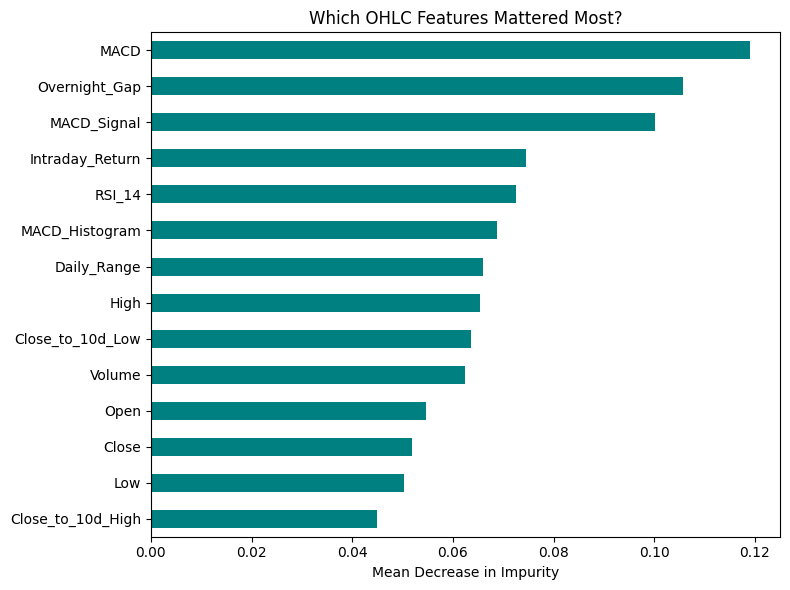

In [6]:
importances = rf_model.feature_importances_
forest_importances = pd.Series(importances, index=feature_cols)

fig, ax = plt.subplots(figsize=(8, 6))
forest_importances.sort_values(ascending=True).plot.barh(ax=ax, color='teal')
ax.set_title("Which OHLC Features Mattered Most?")
ax.set_xlabel("Mean Decrease in Impurity")
fig.tight_layout()
plt.show()